Selected files:
   case_601.parquet
   case_18.parquet
   case_594.parquet
   case_27.parquet
   case_583.parquet
   case_530.parquet
   case_661.parquet
   case_75.parquet
   case_105.parquet
   case_503.parquet


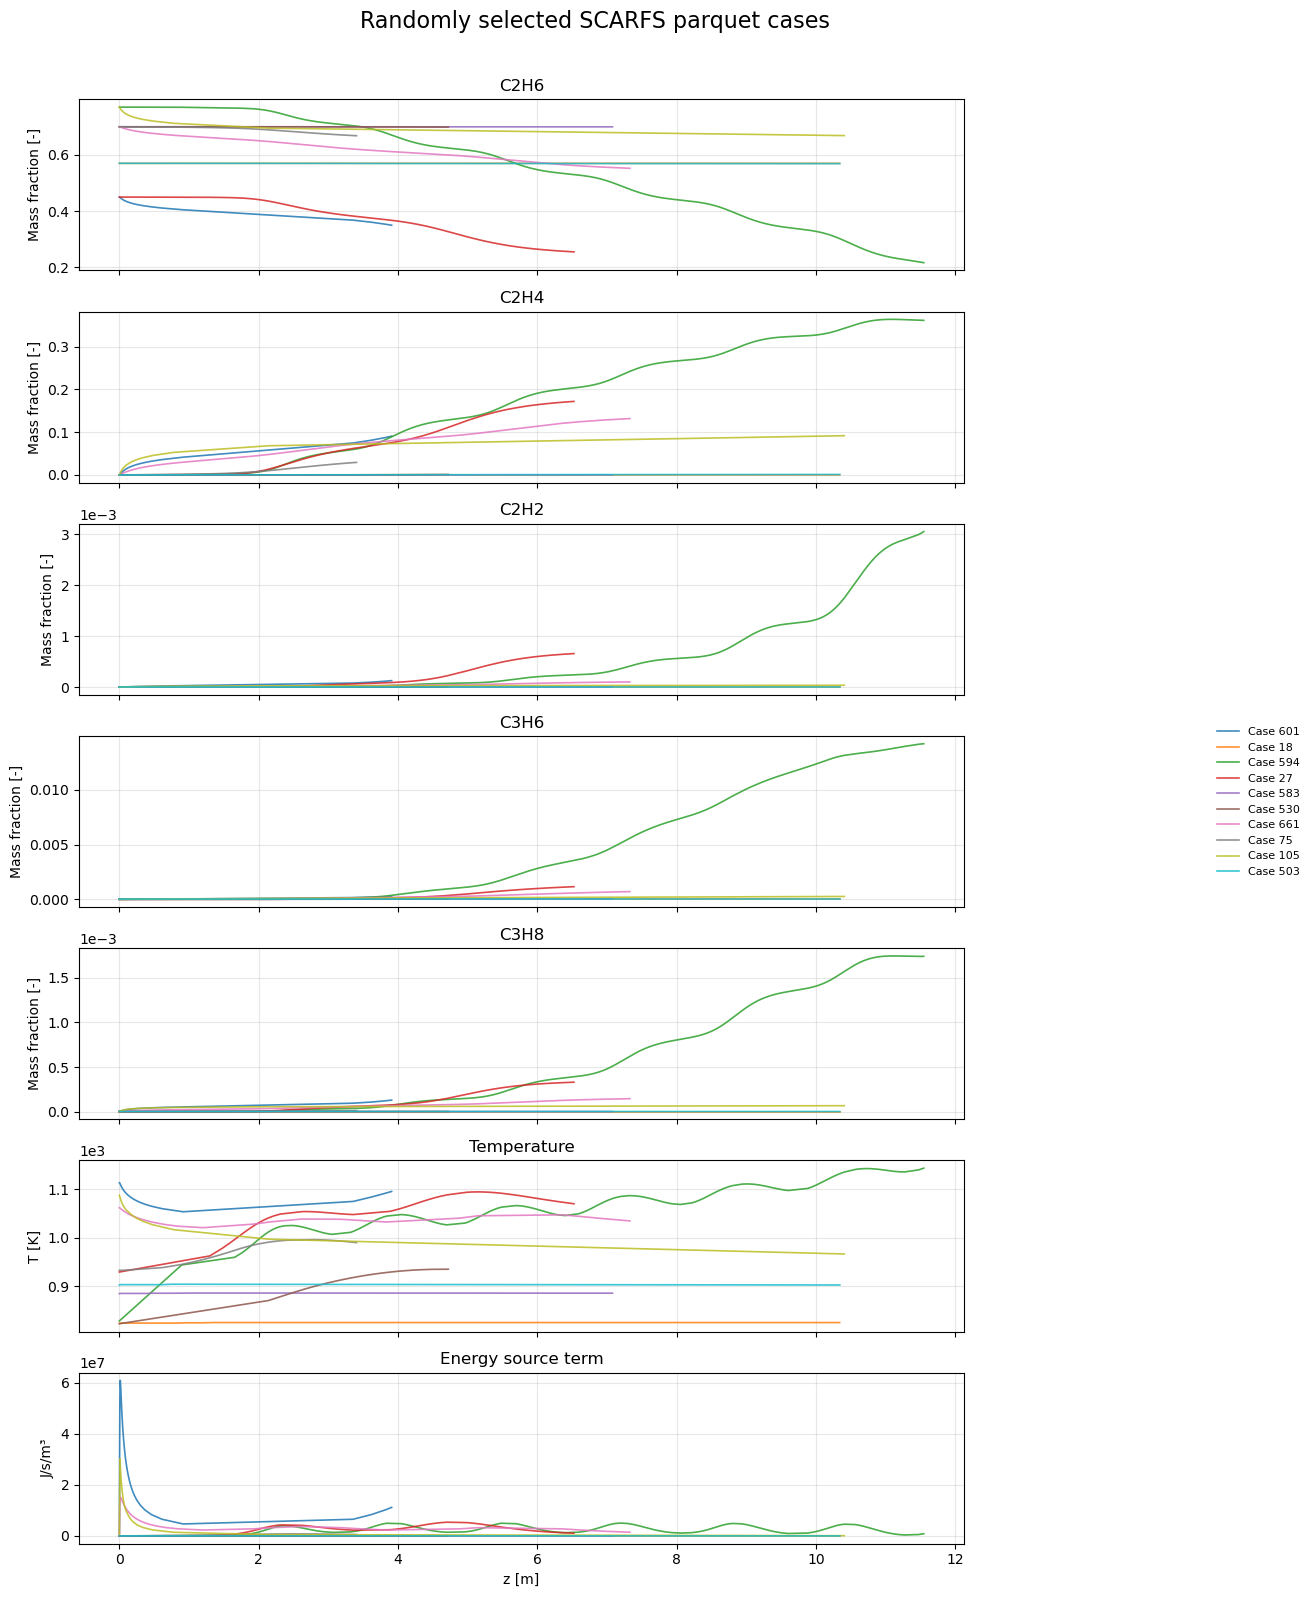


Saved figure to:
C:\Users\mbonheur\OneDrive - UGent\Documenten\GitHub\SCARFS\out_v2\scratch\random_10_case_profiles.png


In [2]:
from pathlib import Path
import random
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# User settings
# ============================================================

FOLDER = Path(
    r"C:\Users\mbonheur\OneDrive - UGent\Documenten\GitHub\SCARFS\out_v2\scratch"
)

N_CASES = 10
MAX_POINTS_PER_CASE = 3000  # downsampling only for plotting speed; set None to disable

# The attached parquet file uses these exact names
SPECIES_COLUMNS = {
    "C2H6": "Y_C2H6",
    "C2H4": "Y_C2H4",
    "C2H2": "Y_C2H2",
    "C3H6": "Y_C3H6",
    "C3H8": "Y_C3H8",
}

TEMPERATURE_CANDIDATES = [
    "T [K]",
    "Temperature [K]",
    "Temperature",
    "T",
]

# In the attached file, this is the energy-source-like column.
# Put "S Wall imposed [J/s/m3]" first here if you prefer plotting the imposed wall source.
ENERGY_SOURCE_CANDIDATES = [
    "!Reaction heat absorption [J/s/m3]",
    "Reaction heat absorption [J/s/m3]",
    "S Wall imposed [J/s/m3]",
    "Energy source term [J/s/m3]",
    "S_h [J/s/m3]",
    "S_h",
]

X_AXIS_CANDIDATES = [
    "z [m]",
    "tau [s]",
    "PFR point index",
]


# ============================================================
# Helper functions
# ============================================================

def natural_key(path: Path):
    """
    Natural sorting: case_2.parquet comes before case_10.parquet.
    """
    return [
        int(text) if text.isdigit() else text.lower()
        for text in re.split(r"(\d+)", path.name)
    ]


def find_column(df: pd.DataFrame, candidates, label: str) -> str:
    """
    Find a column by trying exact matches first, then case-insensitive matches.
    """
    columns = list(df.columns)

    for candidate in candidates:
        if candidate in columns:
            return candidate

    lower_map = {col.lower().strip(): col for col in columns}
    for candidate in candidates:
        key = candidate.lower().strip()
        if key in lower_map:
            return lower_map[key]

    raise KeyError(
        f"Could not find column for {label}.\n"
        f"Tried: {candidates}\n"
        f"Available columns include:\n{columns[:80]}"
    )


def make_case_label(df: pd.DataFrame, file_path: Path) -> str:
    """
    Use CaseID when available; otherwise use the file stem.
    """
    if "CaseID" in df.columns:
        unique_ids = df["CaseID"].dropna().unique()
        if len(unique_ids) > 0:
            return f"Case {unique_ids[0]}"
    return file_path.stem


def downsample_for_plotting(df, max_points):
    """
    Downsample without changing the first/last point of the selected case.
    Works also in Python 3.8 / 3.9.
    """
    if max_points is None or len(df) <= max_points:
        return df

    idx = np.linspace(0, len(df) - 1, max_points).astype(int)
    return df.iloc[idx]

# ============================================================
# Select 10 arbitrary case files
# ============================================================

parquet_files = sorted(FOLDER.glob("*.parquet"), key=natural_key)

if len(parquet_files) < N_CASES + 2:
    raise ValueError(
        f"Need at least {N_CASES + 2} parquet files to exclude the first and last "
        f"and still sample {N_CASES}. Found only {len(parquet_files)}."
    )

# Exclude the first and last file after natural sorting
eligible_files = parquet_files[1:-1]

# Use OS randomness, i.e. not a fixed reproducible seed
rng = random.SystemRandom()
selected_files = rng.sample(eligible_files, N_CASES)

print("Selected files:")
for p in selected_files:
    print("  ", p.name)


# ============================================================
# Read selected cases and identify required columns
# ============================================================

cases = []

for file_path in selected_files:
    df = pd.read_parquet(file_path)

    x_col = find_column(df, X_AXIS_CANDIDATES, "x-axis")
    t_col = find_column(df, TEMPERATURE_CANDIDATES, "temperature")
    e_col = find_column(df, ENERGY_SOURCE_CANDIDATES, "energy source term")

    required_cols = [x_col, t_col, e_col] + list(SPECIES_COLUMNS.values())

    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise KeyError(
            f"Missing required columns in {file_path.name}: {missing}"
        )

    df = df[required_cols + (["CaseID"] if "CaseID" in df.columns else [])].copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[x_col])
    df = df.sort_values(x_col)
    df = downsample_for_plotting(df, MAX_POINTS_PER_CASE)

    label = make_case_label(df, file_path)

    cases.append(
        {
            "file": file_path,
            "label": label,
            "df": df,
            "x_col": x_col,
            "temperature_col": t_col,
            "energy_col": e_col,
        }
    )


# ============================================================
# Plot: one subplot per variable, 10 random cases overlaid
# ============================================================

plot_variables = [
    ("C2H6", "Y_C2H6", "Mass fraction [-]"),
    ("C2H4", "Y_C2H4", "Mass fraction [-]"),
    ("C2H2", "Y_C2H2", "Mass fraction [-]"),
    ("C3H6", "Y_C3H6", "Mass fraction [-]"),
    ("C3H8", "Y_C3H8", "Mass fraction [-]"),
    ("Temperature", cases[0]["temperature_col"], "T [K]"),
    ("Energy source term", cases[0]["energy_col"], "J/s/m³"),
]

fig, axes = plt.subplots(
    nrows=len(plot_variables),
    ncols=1,
    figsize=(12, 16),
    sharex=True,
    constrained_layout=False,
)

for ax, (title, col, ylabel) in zip(axes, plot_variables):
    for case in cases:
        df = case["df"]
        ax.plot(
            df[case["x_col"]],
            df[col],
            linewidth=1.2,
            alpha=0.85,
            label=case["label"],
        )

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    # Scientific notation for very small/large values
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))

axes[-1].set_xlabel(cases[0]["x_col"])

# One shared legend outside the plot area
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    fontsize=8,
    frameon=False,
)

fig.suptitle("Randomly selected SCARFS parquet cases", fontsize=16, y=0.995)
fig.tight_layout(rect=[0, 0, 0.82, 0.985])

output_png = FOLDER / "random_10_case_profiles.png"
fig.savefig(output_png, dpi=300, bbox_inches="tight")

plt.show()

print(f"\nSaved figure to:\n{output_png}")